# DECISION TREE

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.simplefilter('ignore')

### 1. Data Preparation:

In [2]:
data=pd.read_excel('heart_disease.xlsx',sheet_name='Heart_disease')

In [3]:
data

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,53,Male,asymptomatic,125,0,False,normal,120,False,1.5,upsloping,reversable defect,4
904,62,Male,asymptomatic,166,170,False,st-t abnormality,120,True,3.0,flat,reversable defect,4
905,56,Male,non-anginal,170,0,False,lv hypertrophy,123,True,2.5,downsloping,normal,4
906,56,Male,non-anginal,144,208,True,st-t abnormality,105,TURE,NaN,downsloping,fixed defect,4


### 2. Exploratory Data Analysis (EDA):

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [5]:
data.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

In [6]:
data['oldpeak']=data['oldpeak'].fillna(data['oldpeak'].median())

In [7]:
data

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,53,Male,asymptomatic,125,0,False,normal,120,False,1.5,upsloping,reversable defect,4
904,62,Male,asymptomatic,166,170,False,st-t abnormality,120,True,3.0,flat,reversable defect,4
905,56,Male,non-anginal,170,0,False,lv hypertrophy,123,True,2.5,downsloping,normal,4
906,56,Male,non-anginal,144,208,True,st-t abnormality,105,TURE,0.5,downsloping,fixed defect,4


In [8]:
data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: int64

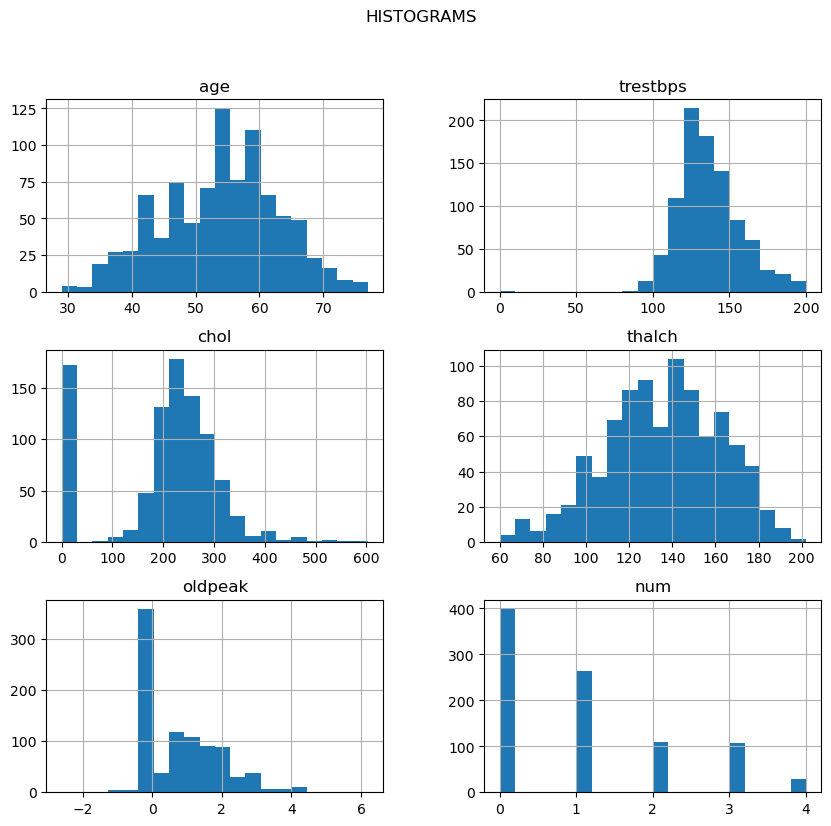

In [10]:
data.hist(bins=20,figsize=(10,9))
plt.suptitle("HISTOGRAMS")
plt.show()

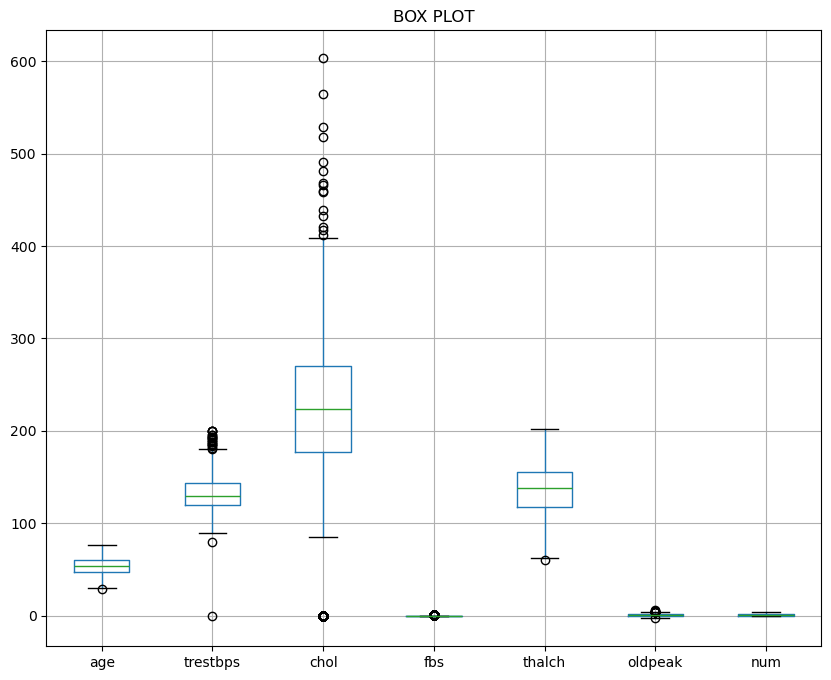

In [11]:
plt.figure(figsize=(10,8))
data.boxplot()
plt.title('BOX PLOT')
plt.show()

### 3. Feature Engineering:

In [12]:
#converting bool to int
data['fbs'] = data['fbs'].astype(int)

In [13]:
data

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,1,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,0,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,0,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,0,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,0,normal,126,True,1.5,flat,fixed defect,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,53,Male,asymptomatic,125,0,0,normal,120,False,1.5,upsloping,reversable defect,4
904,62,Male,asymptomatic,166,170,0,st-t abnormality,120,True,3.0,flat,reversable defect,4
905,56,Male,non-anginal,170,0,0,lv hypertrophy,123,True,2.5,downsloping,normal,4
906,56,Male,non-anginal,144,208,1,st-t abnormality,105,TURE,0.5,downsloping,fixed defect,4


In [14]:
data.dtypes

age           int64
sex          object
cp           object
trestbps      int64
chol          int64
fbs           int32
restecg      object
thalch        int64
exang        object
oldpeak     float64
slope        object
thal         object
num           int64
dtype: object

In [15]:
for column in data.columns:
    if data[column].dtype == 'object':
        data[column] = data[column].astype(str)

In [16]:
data.dtypes

age           int64
sex          object
cp           object
trestbps      int64
chol          int64
fbs           int32
restecg      object
thalch        int64
exang        object
oldpeak     float64
slope        object
thal         object
num           int64
dtype: object

In [17]:
from sklearn.preprocessing import LabelEncoder

In [18]:
categorical_val=data.select_dtypes(include='object').columns
label=LabelEncoder()
for col in categorical_val:
    data[col]=label.fit_transform(data[col])

In [19]:
data.rename(columns={'num':'target'},inplace=True)

In [20]:
data

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,target
0,63,1,3,145,233,1,0,150,1,2.3,0,0,0
1,41,1,1,135,203,0,1,132,1,0.0,1,0,0
2,57,1,0,140,192,0,1,148,1,0.4,1,0,0
3,52,1,3,118,186,0,0,190,1,0.0,1,0,0
4,57,1,0,110,201,0,1,126,3,1.5,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,53,1,0,125,0,0,1,120,1,1.5,2,2,4
904,62,1,0,166,170,0,2,120,3,3.0,1,2,4
905,56,1,2,170,0,0,0,123,3,2.5,0,1,4
906,56,1,2,144,208,1,2,105,2,0.5,0,0,4


In [21]:
corrlaton_matrix=data.corr()

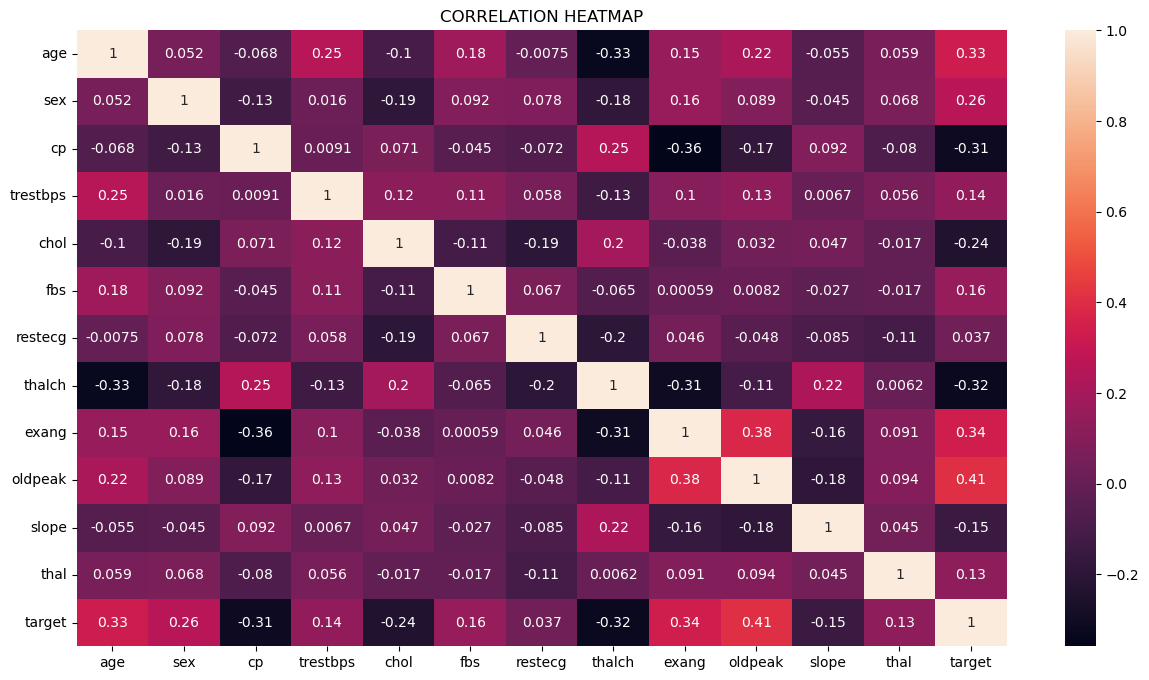

In [22]:
plt.figure(figsize=(15,8))
sns.heatmap(corrlaton_matrix,annot=True)
plt.title('CORRELATION HEATMAP')
plt.show()


### Task-4.Decision Tree Classification:

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.metrics import classification_report

In [24]:
x=data.drop('target',axis=1)
y=data['target']

In [25]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [26]:
model=DecisionTreeClassifier(criterion='entropy',max_depth=3)

In [27]:
model.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3)

In [28]:
y_pred=model.predict(x_test)

In [29]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.61      0.90      0.73       122
           1       0.49      0.41      0.45        82
           2       0.29      0.15      0.20        34
           3       0.40      0.07      0.12        28
           4       0.00      0.00      0.00         7

    accuracy                           0.55       273
   macro avg       0.36      0.31      0.30       273
weighted avg       0.50      0.55      0.50       273



### Task-5. Hyperparameter Tuning:

In [30]:
from sklearn.model_selection import GridSearchCV

In [31]:
params={'criterion':['gini','entropy'],'max_depth':[1,2,3,4,5,6,7],'splitter':['random','best']}

In [32]:
grid=GridSearchCV(model,params)

In [33]:
grid.fit(x_train,y_train)

GridSearchCV(estimator=DecisionTreeClassifier(criterion='entropy', max_depth=3),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [1, 2, 3, 4, 5, 6, 7],
                         'splitter': ['random', 'best']})

In [34]:
grid.best_params_

{'criterion': 'gini', 'max_depth': 3, 'splitter': 'random'}

In [35]:
model2=DecisionTreeClassifier(criterion='gini',max_depth=3,splitter='random')

In [36]:
model2.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=3, splitter='random')

In [37]:
y_pred1=model2.predict(x_test)

In [38]:
print(classification_report(y_test,y_pred1))

              precision    recall  f1-score   support

           0       0.65      0.89      0.75       122
           1       0.43      0.49      0.45        82
           2       0.00      0.00      0.00        34
           3       0.15      0.07      0.10        28
           4       0.00      0.00      0.00         7

    accuracy                           0.55       273
   macro avg       0.25      0.29      0.26       273
weighted avg       0.43      0.55      0.48       273



### Task-6. Model Evaluation and Analysis:

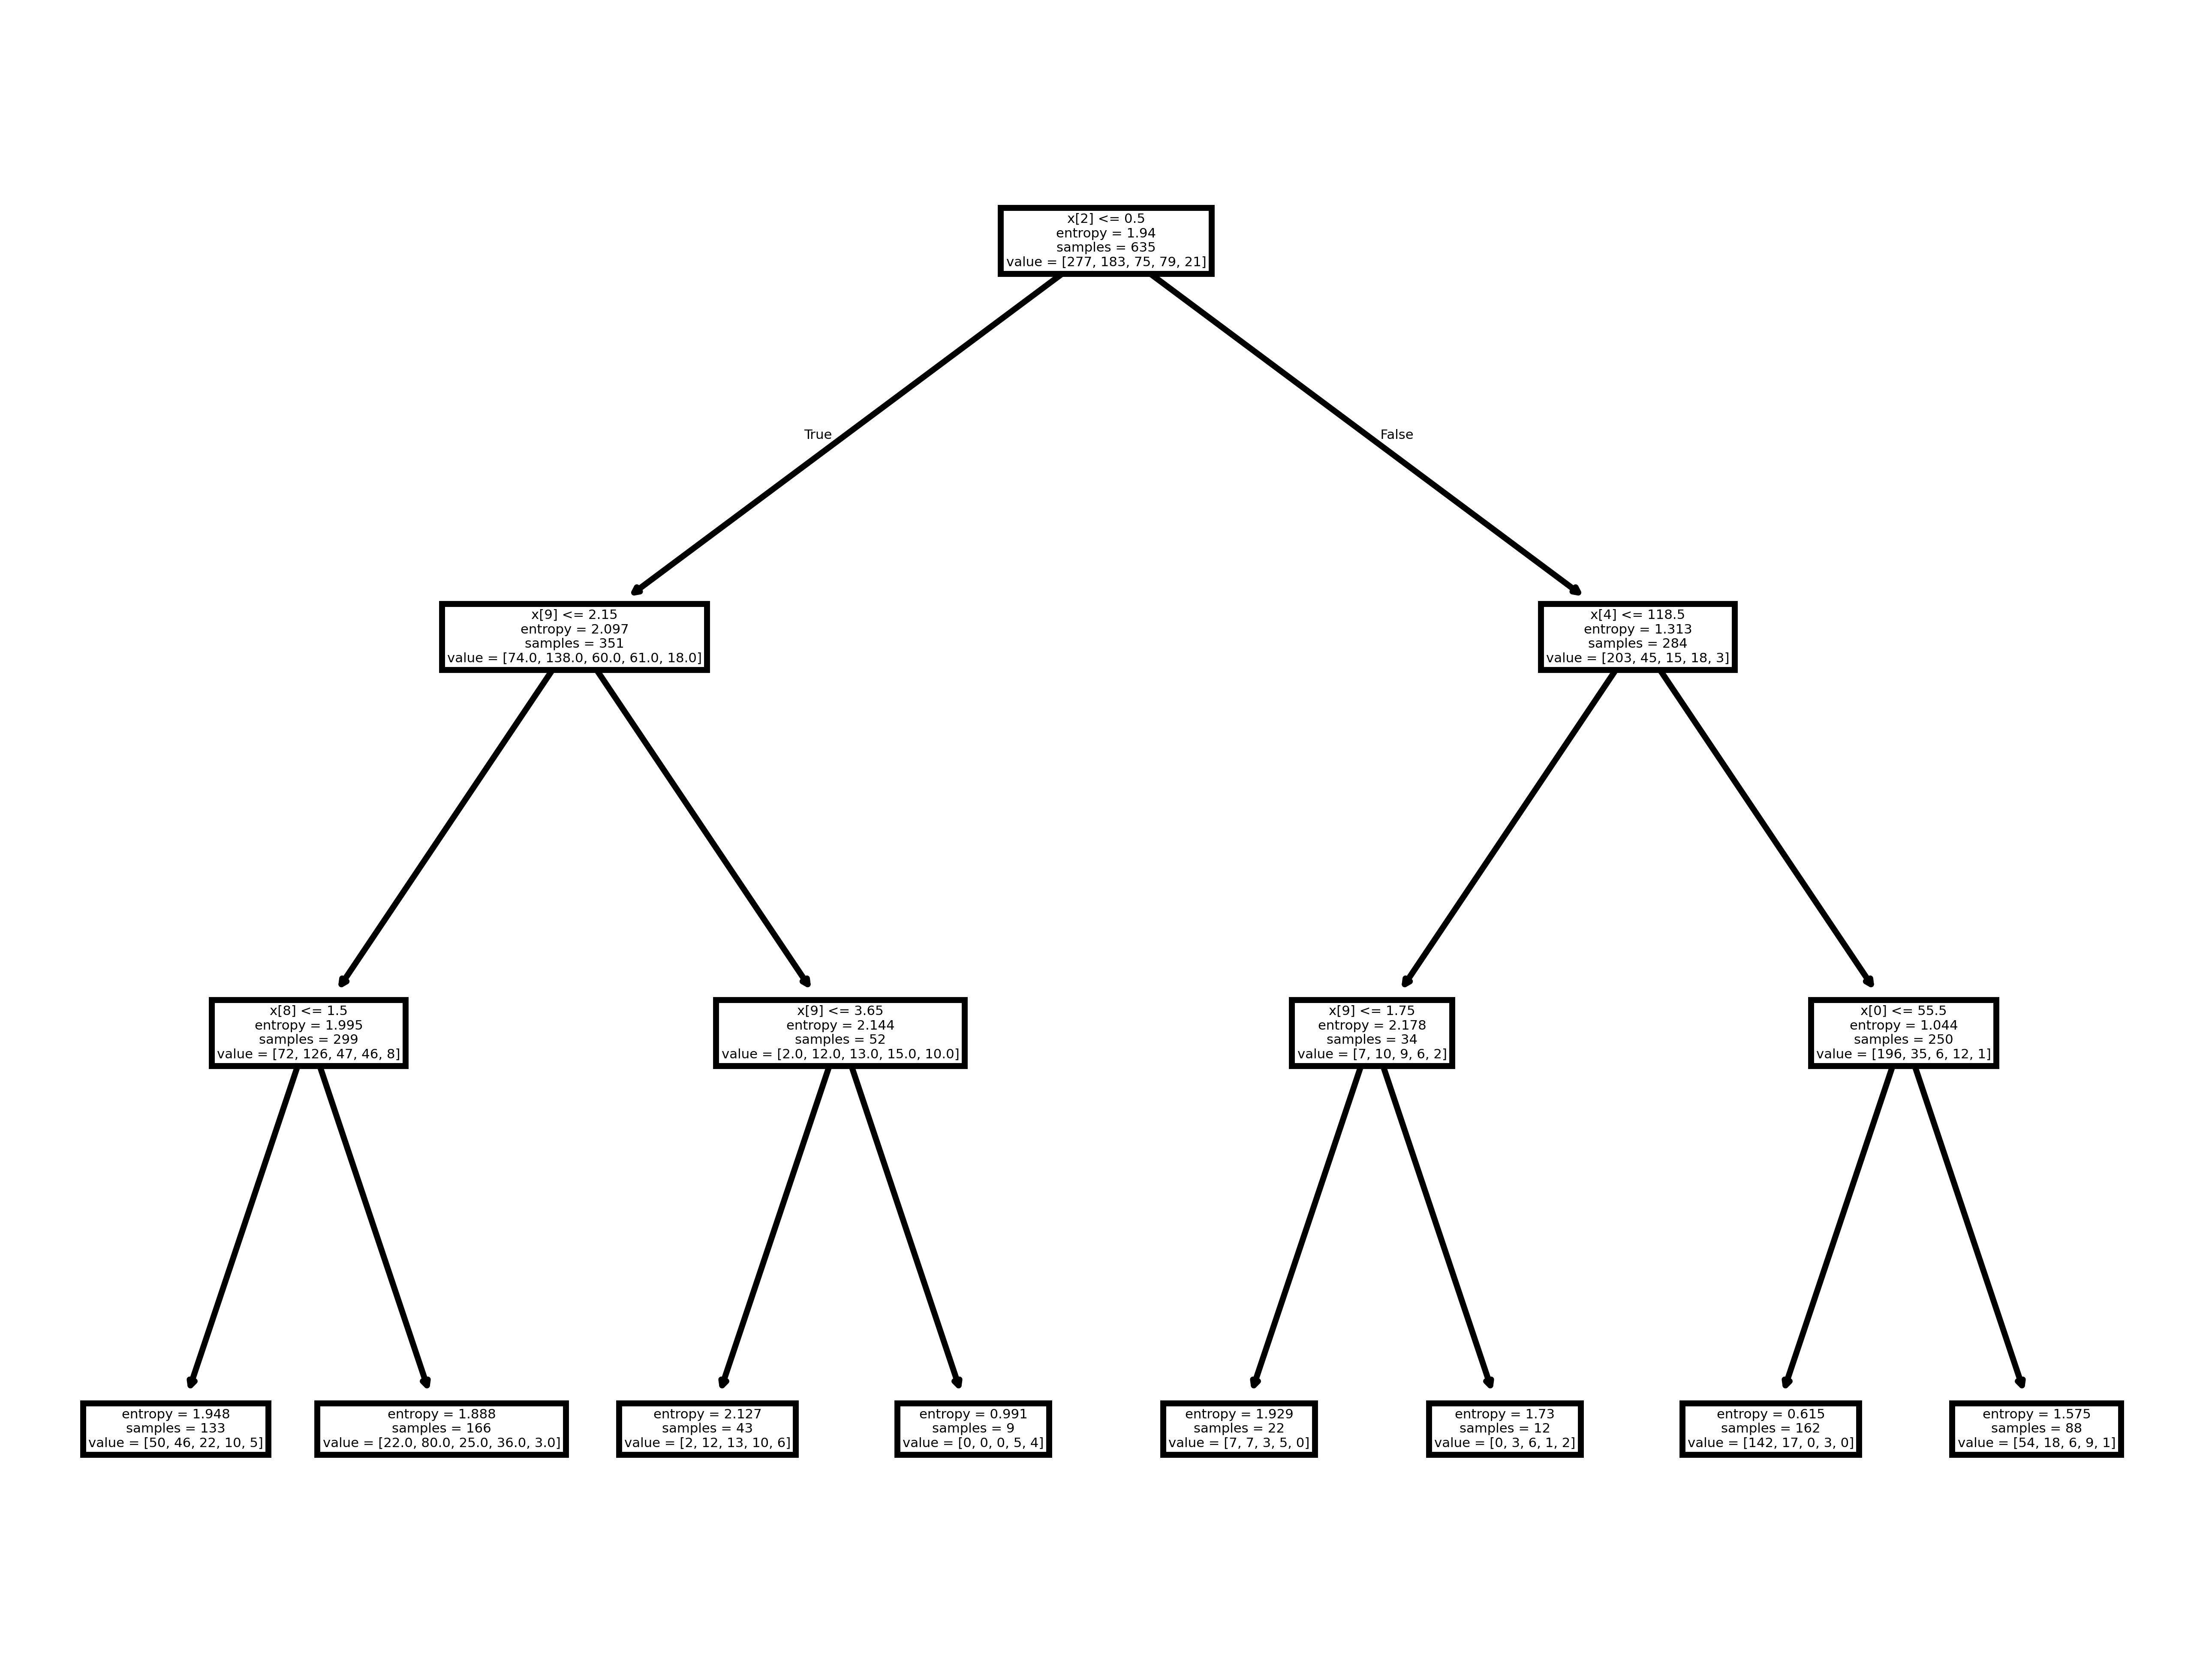

In [39]:
plt.figure(dpi=1000)
tree.plot_tree(model)
plt.show()

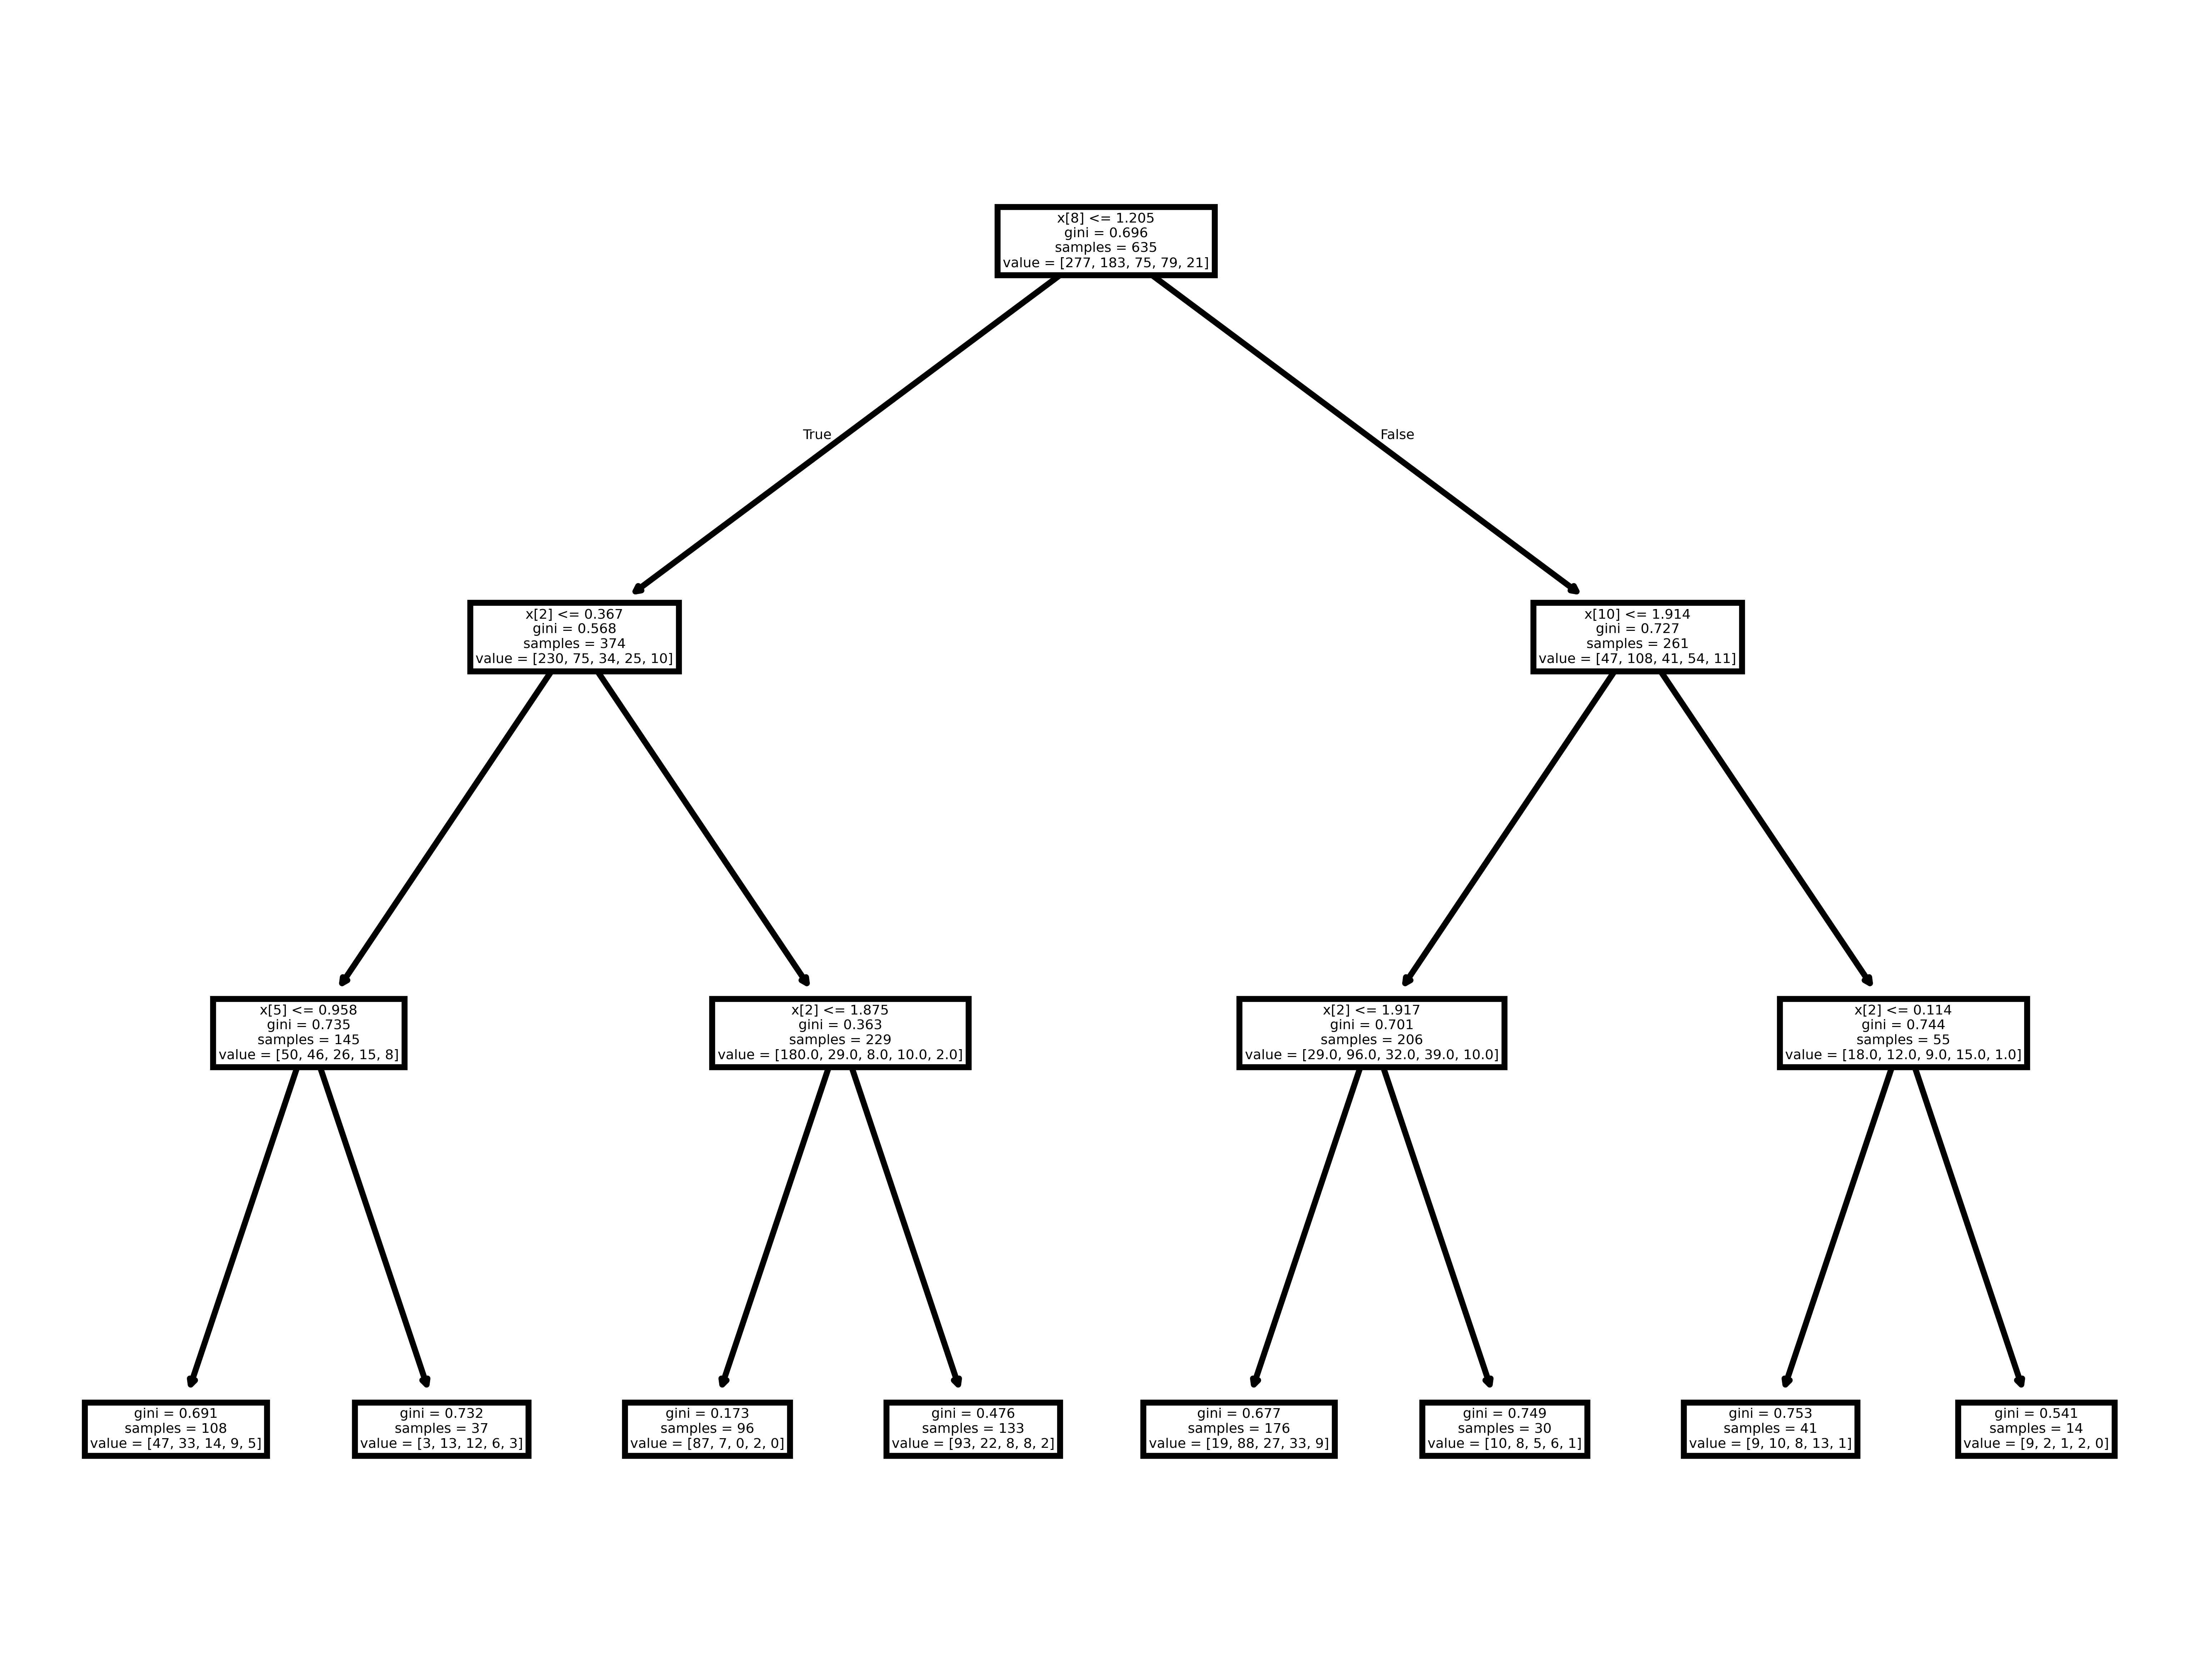

In [40]:
plt.figure(dpi=1200)
tree.plot_tree(model2)
plt.show()

### Interview Questions:

#### 1. Common Decision Tree Hyperparameters:
max_depth: Limits tree depth; prevents overfitting by restricting complexity.
min_samples_split: Minimum samples to split a node; higher values prevent small splits, reducing overfitting.
min_samples_leaf: Minimum samples per leaf; larger leaves reduce overfitting.
criterion: Split quality metric (e.g., gini, entropy); affects purity of nodes.
max_features: Limits features considered per split; helps prevent overfitting and speeds up training.

#### 2. Label Encoding vs. One-Hot Encoding:
Label Encoding converts categories into numeric labels (e.g., Red=0, Blue=1).
It’s simple and memory-efficient.
But it introduces a false ordinal relationship between categories.

One-Hot Encoding creates separate binary columns for each category.
It avoids ordinal issues but increases dimensionality.

Key difference → Label = single column with numbers, One-Hot = multiple columns with 0/1.